In [1]:
# Installing Cudnn
!apt-cache policy c

# Install latest version
!apt install --allow-change-held-packages libcudnn8

# Export env variables
!export PATH=/usr/local/cuda-11.4/bin${PATH:+:${PATH}}
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/lib64:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/include:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda/extras/CUPTI/lib64

N: Unable to locate package c
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libcudnn8
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 444 MB of archives.
After this operation, 1,099 MB of additional disk space will be used.
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  libcudnn8 8.9.7.29-1+cuda12.2 [444 MB]
Fetched 444 MB in 6s (68.8 MB/s)
Selecting previously unselected package libcudnn8.
(Reading database ... 124947 files and directories currently installed.)
Preparing to unpack .../libcudnn8_8.9.7.29-1+cuda12.2_amd64.deb ...
Unpacking libcudnn8 (8.9.7.29-1+cuda12.2) ...
Setting up libcudnn8 (8.9.7.29-1+cuda12.2) ...


In [2]:
import os, glob, time, random, pickle, cv2, shutil, gdown, re
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.gridspec as gridspec

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses, callbacks
from tensorflow.keras import backend as K
import tensorboard
from tensorflow.keras.saving import register_keras_serializable
%matplotlib inline

In [3]:
#original Link
# https://drive.google.com/file/d/162oRpsX7JVSX2jjDLYvxrkqsVa_3CBIG/view?usp=sharing

# Global Variables
FILE_ID = "1tkKn01cnF3MH7-8mQzIay7ShMcgdZXF7"
tf.keras.utils.set_random_seed(200)
height, width = 64, 64
BATCH_SIZE=256
channels = 3

In [4]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        # using gdown to download the data set from url id
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")

    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

def download_and_prep_dataset(FILE_ID, folderName=""):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "dataSet/animefacedataset.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)

    # Load the dataset
    data_path = os.path.join(extractPath, "content/animefacedataset/")
    return data_path

In [5]:
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)

CWD:  /content


Downloading...
From (original): https://drive.google.com/uc?id=1tkKn01cnF3MH7-8mQzIay7ShMcgdZXF7
From (redirected): https://drive.google.com/uc?id=1tkKn01cnF3MH7-8mQzIay7ShMcgdZXF7&confirm=t&uuid=0dfb2eeb-682c-43c5-9e84-995a504734a4
To: /content/dataSet/animefacedataset.zip
100%|██████████| 418M/418M [00:03<00:00, 117MB/s]


Successfully downloaded to /content/dataSet/animefacedataset.zip
Successfully extracted to /content/unzipLoc


In [6]:
print(dl_ext_data_path)
imageData = keras.preprocessing.image_dataset_from_directory(directory=dl_ext_data_path, label_mode=None, image_size=(height, width), batch_size=BATCH_SIZE, shuffle=True)
scaledImg = imageData.map(lambda x: ((x - 127.5)/(127.5)))

/content/unzipLoc/content/animefacedataset/
Found 63565 files.


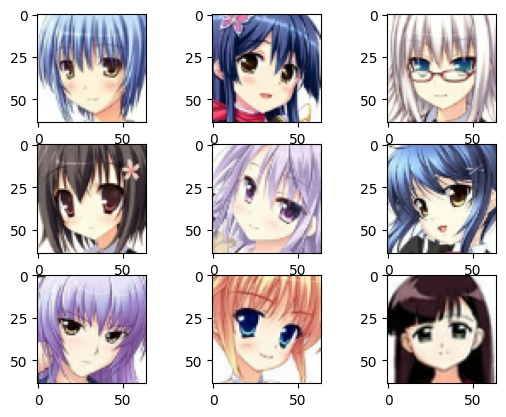

In [7]:
# Display grid of images from dataset
def display_images(total=9, dataSet=None): # default total images to display = 9
    num=total
    for x in dataSet:
        plt.subplot(330 + 1 + total - num)
        plt.imshow(( (x.numpy()*0.5 + 0.5) * 255).astype("int32")[0]) #pyplot.imshow((x.numpy() * 255).astype("int32")[0])
        num-=1
        if not num:
            break

display_images(dataSet=scaledImg)

Image Dimensions:  (256, 64, 64, 3)


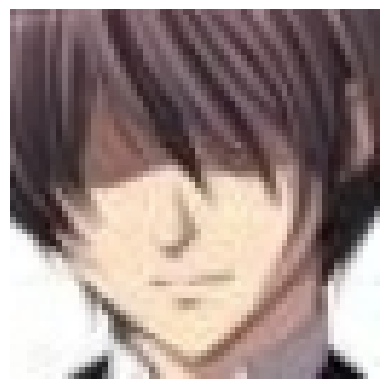

In [8]:
def display_single(dataset=None):
    for x in dataset:
        plt.axis("off")
        print("Image Dimensions: ",x.numpy().shape)
        plt.imshow(((x.numpy()*0.5 + 0.5) * 255).astype("int32")[0])
        break

display_single(dataset=scaledImg)

In [9]:
# model Building Discriminator

def get_disc_model(inputShape=(64, 64)):
  height, width = inputShape
  dropoutRate = 0.4
  l2Reg = keras.regularizers.l2(0.0001)

  inpLayer = keras.Input(shape=(height, width, channels))
  conv2D_1 = keras.layers.Conv2D(64, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(inpLayer)
  conv2D_1 = keras.layers.LeakyReLU(0.2)(conv2D_1)

  conv2D_2 = keras.layers.Conv2D(128, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(conv2D_1)
  conv2D_2 = keras.layers.BatchNormalization()(conv2D_2)
  conv2D_2 = keras.layers.LeakyReLU(0.2)(conv2D_2)

  conv2D_3 = keras.layers.Conv2D(256, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(conv2D_2)
  conv2D_3 = keras.layers.BatchNormalization()(conv2D_3)
  conv2D_3 = keras.layers.LeakyReLU(0.2)(conv2D_3)

  conv2D_4 = keras.layers.Conv2D(512, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(conv2D_3)
  conv2D_4 = keras.layers.BatchNormalization()(conv2D_4)
  conv2D_4 = keras.layers.LeakyReLU(0.2)(conv2D_4)

  flatten = keras.layers.Flatten()(conv2D_4)
  dropout = keras.layers.Dropout(dropoutRate)(flatten)
  output = keras.layers.Dense(1, activation="sigmoid")(dropout)

  disc_model = keras.Model(inputs=inpLayer, outputs=output, name="discriminator")
  return disc_model

In [10]:
def get_generator_model(inputShape=(1, 1, 128)):
  dropoutRate = 0.4
  l2Reg = keras.regularizers.l2(0.0001)

  inpLayer = keras.Input(shape=inputShape)

  conv2D_1 = keras.layers.Conv2DTranspose(512, (4, 4), strides=(1, 1), padding="valid", kernel_regularizer=l2Reg)(inpLayer)
  conv2D_1 = keras.layers.BatchNormalization()(conv2D_1)
  conv2D_1 = keras.layers.ReLU()(conv2D_1)

  conv2D_2 = keras.layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(conv2D_1)
  conv2D_2 = keras.layers.BatchNormalization()(conv2D_2)
  conv2D_2 = keras.layers.ReLU()(conv2D_2)

  conv2D_3 = keras.layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(conv2D_2)
  conv2D_3 = keras.layers.BatchNormalization()(conv2D_3)
  conv2D_3 = keras.layers.ReLU()(conv2D_3)

  conv2D_4 = keras.layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg)(conv2D_3)
  conv2D_4 = keras.layers.BatchNormalization()(conv2D_4)
  conv2D_4 = keras.layers.ReLU()(conv2D_4)

  output = keras.layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding="same", kernel_regularizer=l2Reg, activation="tanh")(conv2D_4)
  gen_model = keras.Model(inputs=inpLayer, outputs=output, name="generator")

  return gen_model

In [11]:
class GANModel(keras.Model):
  def __init__(self, discriminator, generator, randEmbShape) -> None:
      super(GANModel, self).__init__()
      self.discriminator = discriminator
      self.generator = generator
      self.randEmbShape = randEmbShape

  def compile(self, d_optimizer, g_optimizer, loss_fn):
      super(GANModel, self).compile()
      self.d_optimizer = d_optimizer
      self.g_optimizer = g_optimizer
      self.loss_fn = loss_fn
      self.d_loss_Metric = keras.metrics.Mean(name="d_loss")
      self.g_loss_Metric = keras.metrics.Mean(name="g_loss")

  @property
  def metrics(self):
      return [self.d_loss_Metric, self.g_loss_Metric]

  def train_step(self, real_images):
    batch_size = tf.shape(real_images)[0]

    randEmb = tf.random.normal(shape=(batch_size, ) + self.randEmbShape)

    fake_images = self.generator(randEmb, training=True)

    combinedImgs = tf.concat([real_images, fake_images], axis=0)
    labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)

    with tf.GradientTape() as tape:
      predictions = self.discriminator(combinedImgs)
      d_loss = self.loss_fn(labels, predictions)
    grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
    self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

    randEmb = tf.random.normal(shape=(batch_size, ) + self.randEmbShape)
    misleading_labels = tf.ones((batch_size, 1))

    with tf.GradientTape() as tape:
      predictions = self.discriminator(self.generator(randEmb))
      g_loss = self.loss_fn(misleading_labels, predictions)
    grads = tape.gradient(g_loss, self.generator.trainable_weights)
    self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

    self.d_loss_Metric.update_state(d_loss)
    self.g_loss_Metric.update_state(g_loss)

    return {"d_loss": self.d_loss_Metric.result(), "g_loss": self.g_loss_Metric.result()}

In [14]:
def save_img_batch(img_batch, img_save_dir):
  img_batch.numpy()
  plt.figure(figsize=(4,4))
  gs1 = gridspec.GridSpec(4, 4)
  gs1.update(wspace=0, hspace=0)
  # Ensure sample size does not exceed population size
  num_samples = min(img_batch.shape[0], 16)  # Change here
  rand_indices = np.random.choice(img_batch.shape[0], num_samples, replace=False)  # Change here
  # Iterate over the selected number of samples
  for i in range(num_samples):  # Change here
      ax1 = plt.subplot(gs1[i])
      ax1.set_aspect('equal')
      rand_index = rand_indices[i]
      image = img_batch[rand_index, :,:,:]
      fig = plt.imshow(image)
      plt.axis('off')
      fig.axes.get_xaxis().set_visible(False)
      fig.axes.get_yaxis().set_visible(False)
  plt.tight_layout()
  plt.savefig(img_save_dir,bbox_inches='tight',pad_inches=0)
  plt.show()

class GANMonitor(keras.callbacks.Callback):
  def __init__(self, num_img=9, latent_dim=(1,1,128), file_writer=None) -> None:
    super(GANMonitor, self).__init__()
    self.num_img = num_img
    self.latent_dim = latent_dim
    self.file_writer = file_writer
    self.randomEmbedding = tf.random.normal(shape=((self.num_img,) + self.latent_dim))
    self.path = os.path.abspath(os.path.join(os.getcwd(), "GAN_Images"))
    if not os.path.exists(self.path):
      os.mkdir(self.path)

  def on_epoch_end(self, epoch, logs=None):
    generated_images = self.model.generator(self.randomEmbedding)
    generated_images = (( (generated_images * 0.5) + 0.5 ) * 255)
    generated_images = tf.cast(generated_images, dtype=tf.int64)

    save_img_batch(generated_images, self.path + '/' + 'generated_img_%03d.png' % (epoch) )
    with self.file_writer.as_default():
      tf.summary.image("Epoch end generated data", generated_images, step=epoch)


Epoch 1/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - d_loss: 0.1056 - g_loss: 0.8736

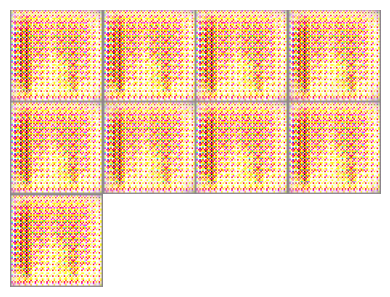

249/249 ━━━━━━━━━━━━━━━━━━━━ 91s 323ms/step - d_loss: 0.1054 - g_loss: 0.8735
Epoch 2/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - d_loss: 5.9658e-04 - g_loss: 0.5702

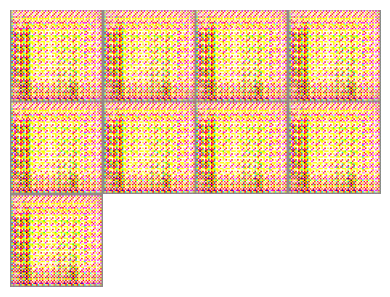

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 297ms/step - d_loss: 5.9580e-04 - g_loss: 0.5710
Epoch 3/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 1.5930e-04 - g_loss: 1.6944

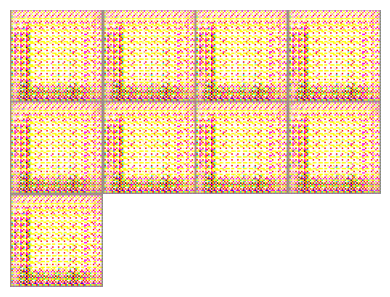

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - d_loss: 1.5929e-04 - g_loss: 1.6955
Epoch 4/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 1.2377e-04 - g_loss: 3.2495

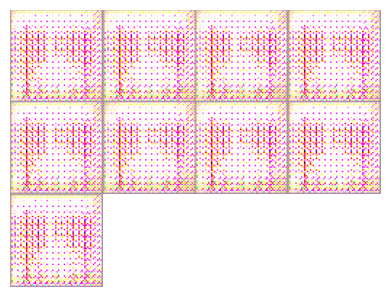

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - d_loss: 1.2385e-04 - g_loss: 3.2500
Epoch 5/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 6.8348e-04 - g_loss: 3.9445

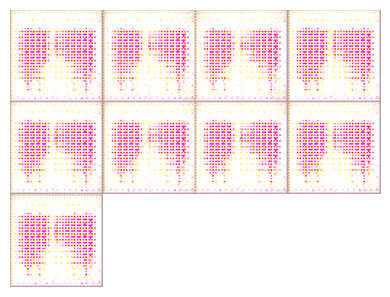

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - d_loss: 6.8422e-04 - g_loss: 3.9468
Epoch 6/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - d_loss: 4.0130e-04 - g_loss: 3.9510

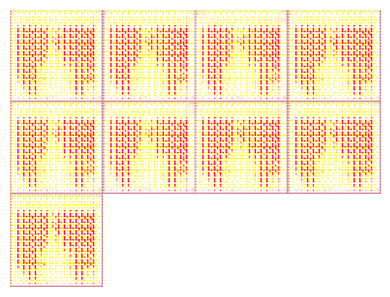

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 296ms/step - d_loss: 4.0101e-04 - g_loss: 3.9469
Epoch 7/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 3.1842e-05 - g_loss: 4.7236

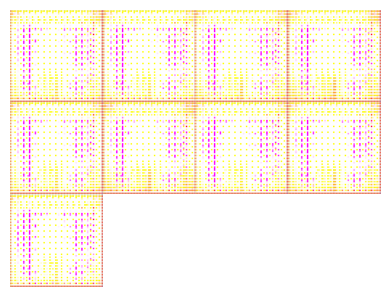

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - d_loss: 3.1958e-05 - g_loss: 4.7283
Epoch 8/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 2.9842e-04 - g_loss: 6.9308

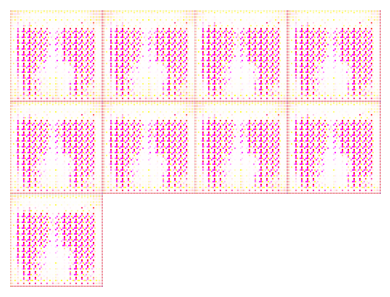

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - d_loss: 2.9946e-04 - g_loss: 6.9305
Epoch 9/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 1.7968e-04 - g_loss: 7.6506

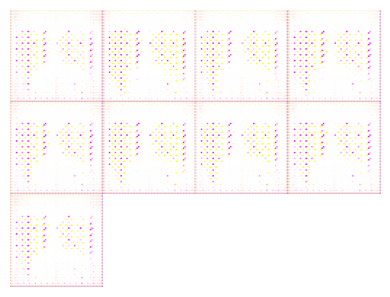

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - d_loss: 1.7953e-04 - g_loss: 7.6550
Epoch 10/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - d_loss: 6.7608e-05 - g_loss: 10.3455

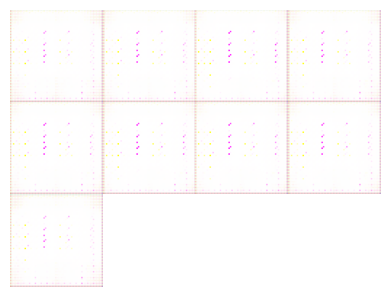

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 296ms/step - d_loss: 6.7647e-05 - g_loss: 10.3471
Epoch 11/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - d_loss: 4.2700e-05 - g_loss: 10.1953

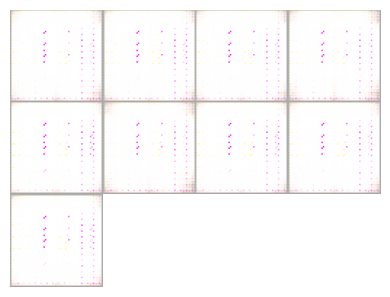

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 296ms/step - d_loss: 4.2720e-05 - g_loss: 10.1951
Epoch 12/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 1.1920e-04 - g_loss: 8.3588

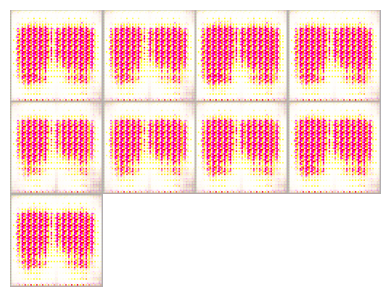

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - d_loss: 1.1957e-04 - g_loss: 8.3459
Epoch 13/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - d_loss: 1.0980e-04 - g_loss: 0.0667

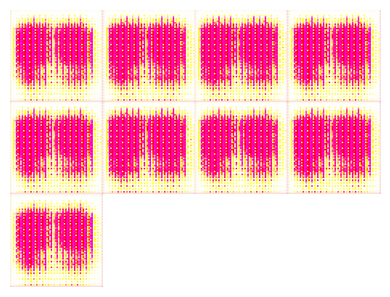

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 298ms/step - d_loss: 1.0964e-04 - g_loss: 0.0669
Epoch 14/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - d_loss: 2.4197e-05 - g_loss: 0.3853

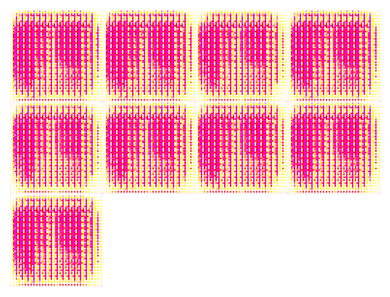

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 296ms/step - d_loss: 2.4190e-05 - g_loss: 0.3858
Epoch 15/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - d_loss: 1.1741e-05 - g_loss: 1.8788

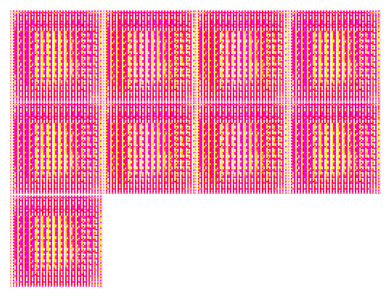

249/249 ━━━━━━━━━━━━━━━━━━━━ 83s 299ms/step - d_loss: 1.1749e-05 - g_loss: 1.8864
Epoch 16/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - d_loss: 4.3076e-06 - g_loss: 9.1639

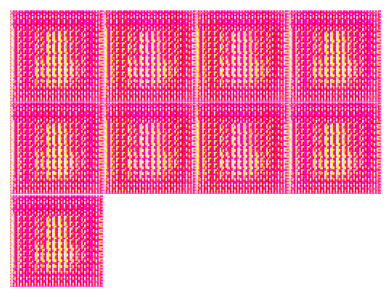

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - d_loss: 4.3076e-06 - g_loss: 9.1668
Epoch 17/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - d_loss: 2.1616e-06 - g_loss: 11.1262

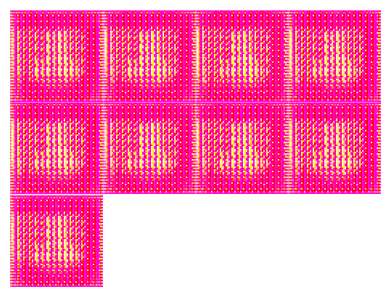

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 297ms/step - d_loss: 2.1626e-06 - g_loss: 11.1266
Epoch 18/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - d_loss: 9.0614e-07 - g_loss: 12.0433

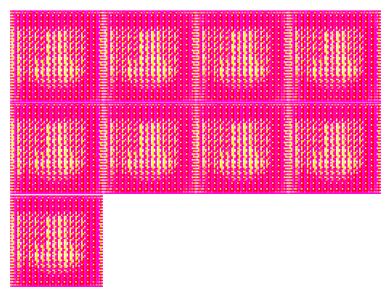

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - d_loss: 9.0648e-07 - g_loss: 12.0443
Epoch 19/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - d_loss: 4.9980e-07 - g_loss: 13.1300

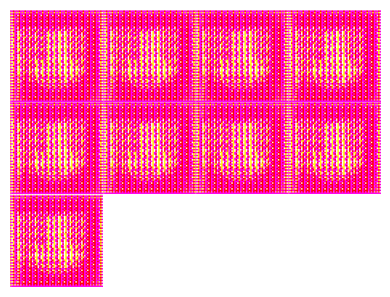

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - d_loss: 5.0012e-07 - g_loss: 13.1305
Epoch 20/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - d_loss: 3.3781e-07 - g_loss: 13.7418

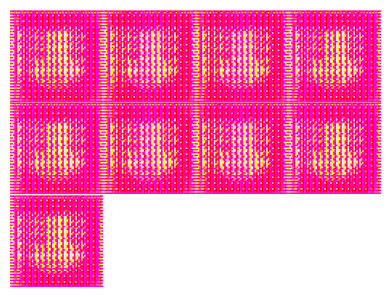

249/249 ━━━━━━━━━━━━━━━━━━━━ 74s 296ms/step - d_loss: 3.3807e-07 - g_loss: 13.7424
Epoch 21/60
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - d_loss: 2.3973e-07 - g_loss: 14.3592

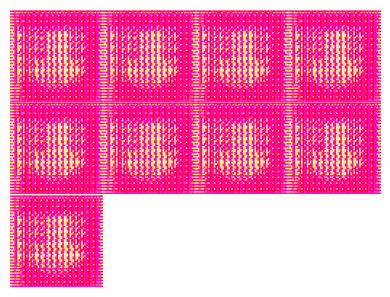

249/249 ━━━━━━━━━━━━━━━━━━━━ 82s 297ms/step - d_loss: 2.3992e-07 - g_loss: 14.3597
Epoch 22/60
 23/249 ━━━━━━━━━━━━━━━━━━━━ 1:04 287ms/step - d_loss: 1.1990e-07 - g_loss: 14.7638

KeyboardInterrupt: 

In [15]:
epoch = 60
batch_size = 512
latentDim = (1, 1, 128)
image_dimensions = (64, 64)

generator = get_generator_model(inputShape=latentDim)
discriminator = get_disc_model(inputShape=image_dimensions)

a = keras.utils.plot_model(discriminator, to_file="Descriminator_model.jpg" ,show_shapes=True, show_dtype=True)
a = keras.utils.plot_model(generator, to_file="Generator_model.jpg", show_shapes=True, show_dtype=True)

training_log_dir = './mode_collapse_logs/training_logs'
epoch_end_logdir = './mode_collapse_logs/epoch_end_logs'

file_writer = tf.summary.create_file_writer(epoch_end_logdir)

ganModel = GANModel(discriminator=discriminator,
                    generator=generator,
                    randEmbShape=latentDim)

ganModel.compile(d_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                 g_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
                 loss_fn=keras.losses.BinaryCrossentropy())

ganModel.fit(scaledImg,
             epochs=epoch,
             callbacks=[GANMonitor(num_img=9, latent_dim=(1,1,128), file_writer=file_writer)])
